In [7]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import load_results
# Execute the loader and show a quick summary/preview
df_translation = load_results("../results/translation", "roh_translational_accuracy*.json")
df_negation = load_results("../results/translation", "roh_translational_negation*.json")

train_df = pd.read_json("../results/training/aggregated_results.json")
train_df = train_df.rename(columns={"weight_decay": "wd"})
# Plot style
sns.set_theme(style="ticks")

In [8]:
# Define thresholds for grouping
threshold_low = 0.4
threshold_high = 0.98

# Create masks for the two groups based on train_df
mask_g1 = (train_df['reverse_uni_acc'] < threshold_low)
mask_g2 = train_df['reverse_uni_acc'] > threshold_high

# Get the runs for each group
g1_runs = train_df[mask_g1][['wd', 'seed']]
g2_runs = train_df[mask_g2][['wd', 'seed']]

# Filter df based on Subfolder matching the runs
# Create tuples for matching
g1_tuples = set(zip(g1_runs['wd'], g1_runs['seed']))
g2_tuples = set(zip(g2_runs['wd'], g2_runs['seed']))

# df_bilinear, df_composition, df_transpose
df_g1 = df_translation[df_translation[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_translation[df_translation[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()

# Add group labels
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'
# Combine into one dataframe if needed
df_translation = pd.concat([df_g1, df_g2], ignore_index=True)

df_g1 = df_negation[df_negation[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_negation[df_negation[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'

df_negation = pd.concat([df_g1, df_g2], ignore_index=True)

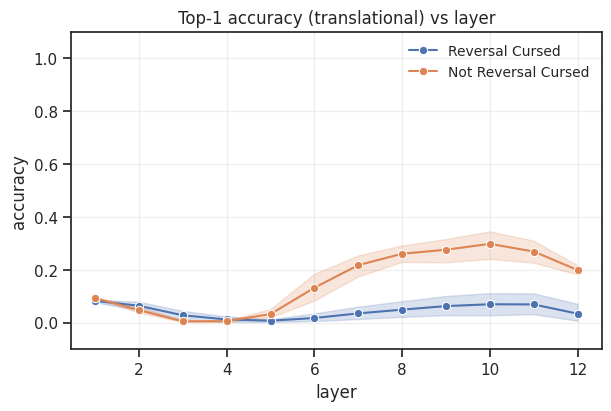

In [9]:
df_overall = df_translation[(df_translation['relation'] == 'overall') & (df_translation['layer'] > 0)]
# Plot with the corrected data
sns.set_theme(style="ticks")

fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
sns.lineplot(data=df_overall, x='layer', y='accuracy', hue='group', marker='o')
ax.legend(title_fontsize='13', fontsize='10', frameon=False)
ax.set_title('Top-1 accuracy (translational) vs layer')
ax.set_xlabel('layer')
ax.set_ylabel('accuracy')
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)


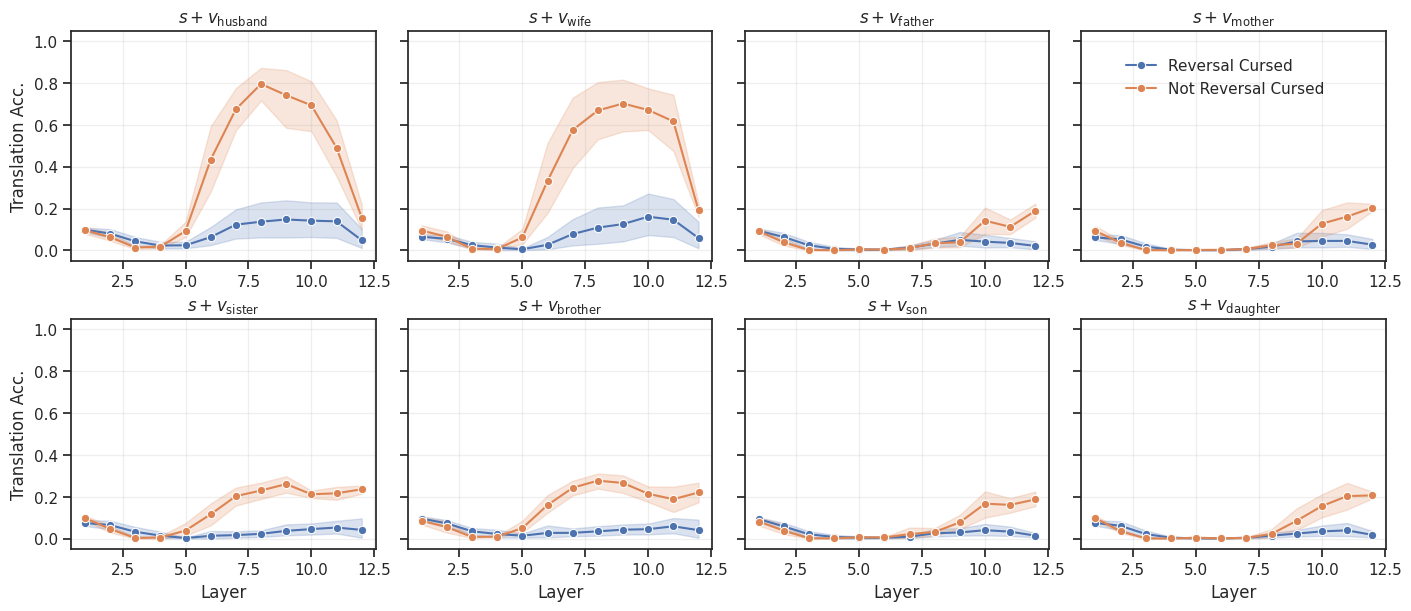

In [10]:
# Map weight decay keys to meaningful labels
rels = ["husband", "wife", "father", "mother", "sister", "brother", "son", "daughter"]
# Plot
fig, axes = plt.subplots(2, 4, figsize=(14, 6), constrained_layout=True)

latex_expression = {"husband": r"v_{\text{husband}}", "wife": r"v_{\text{wife}}", "father": r"v_{\text{father}}", "mother": r"v_{\text{mother}}", "sister": r"v_{\text{sister}}", "brother": r"v_{\text{brother}}", "son": r"v_{\text{son}}", "daughter": r"v_{\text{daughter}}"}

for i, rel in enumerate(rels):
    ax = axes[i // 4, i % 4]
    rel_df = df_translation[(df_translation['relation'] == rel) & (df_translation['layer'] > 0)]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=i==3
    )
    ax.set_title(f'$s + {latex_expression[rel]}$')
    ax.set_xlabel('layer')
    ax.set_ylabel('accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Only show y-label on leftmost column
    if i % 4 == 0:
        ax.set_ylabel('Translation Acc.')
    else:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)

    if i // 4 == 1:
        ax.set_xlabel('Layer')
    else:
        ax.set_xlabel('')
    if i == 3:
        ax.legend_.remove()
        handles, labels = ax.get_legend_handles_labels()
        
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.79, 0.88),
            frameon=False
        )

plt.savefig("SM-translation_acc_over_relations.pdf", bbox_inches='tight')

In [11]:
df_negation.relation.unique()

array(['husband', 'sister', 'brother', 'wife'], dtype=object)

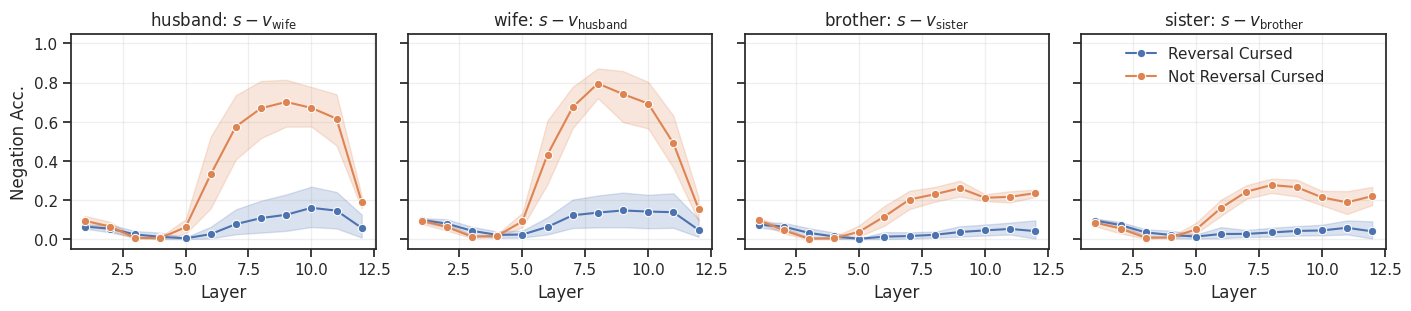

In [12]:
# df_negation
rels = ['husband', 'wife', 'brother', 'sister']
latex_expression = {"husband": r"v_{\text{wife}}", "wife": r"v_{\text{husband}}", "father": r"v_{\text{father}}", "mother": r"v_{\text{mother}}", "sister": r"v_{\text{brother}}", "brother": r"v_{\text{sister}}", "son": r"v_{\text{son}}", "daughter": r"v_{\text{daughter}}"}
# Plot for negation accuracy by relation
fig, axes = plt.subplots(1, 4, figsize=(14, 3), constrained_layout=True)

for i, rel in enumerate(rels):
    ax = axes[i]
    rel_df = df_negation[(df_negation['relation'] == rel) & (df_negation['layer'] > 0)]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='negation_accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=i==3
    )
    ax.set_title(f'{rel}: $s - {latex_expression[rel]}$')
    ax.set_xlabel('Layer')
    ax.set_ylabel('negation accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Only show y-label on leftmost column
    if i % 4 == 0:
        ax.set_ylabel('Negation Acc.')
    else:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)
    if i == 3:
        ax.legend_.remove()
        handles, labels = ax.get_legend_handles_labels()
        
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.79, 0.8),
            frameon=False
        )

plt.savefig("SM-translation_negation.pdf", bbox_inches='tight')